In [1]:
from google.colab import files
uploaded = files.upload()

Saving steam_games_dataset.csv to steam_games_dataset.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving vgsales.csv to vgsales.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving games.csv to games.csv


Dataset loaded: 83,035 rows, 15 columns

HYPOTHESIS 1: Free vs Paid Games — Popularity
Free games  — Median reviews: 16
Paid games  — Median reviews: 51
Mann-Whitney U statistic: 574,196,402
P-value: 1.000000
Result: FAIL TO REJECT H0 — No significant difference found.


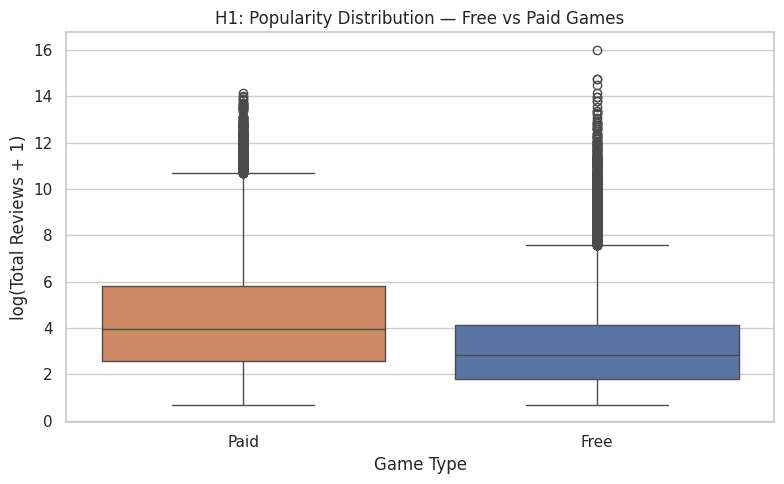

Saved: h1_free_vs_paid.png

HYPOTHESIS 2: Price Category vs Popularity
Median reviews by price category:
price_category
Free           16.0
$0.01-$9.99    51.0

Kruskal-Wallis statistic: 5692.3214
P-value: 0.000000
Result: REJECT H0 — Popularity differs significantly across price categories.


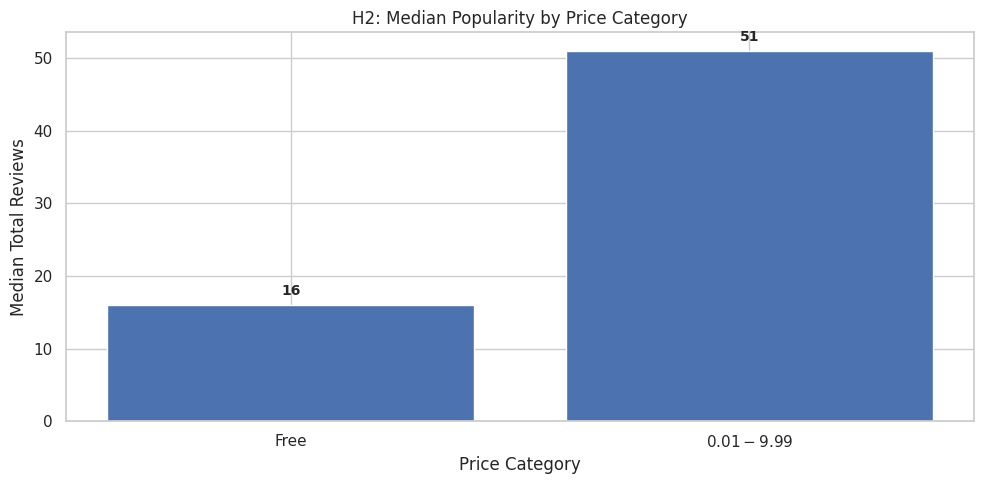

Saved: h2_price_category.png

HYPOTHESIS 3: Playtime vs Popularity
Games with playtime data: 7,896
Spearman correlation (r): 0.4919
P-value: 0.000000
Result: REJECT H0 — There is a significant positive correlation between playtime and popularity.


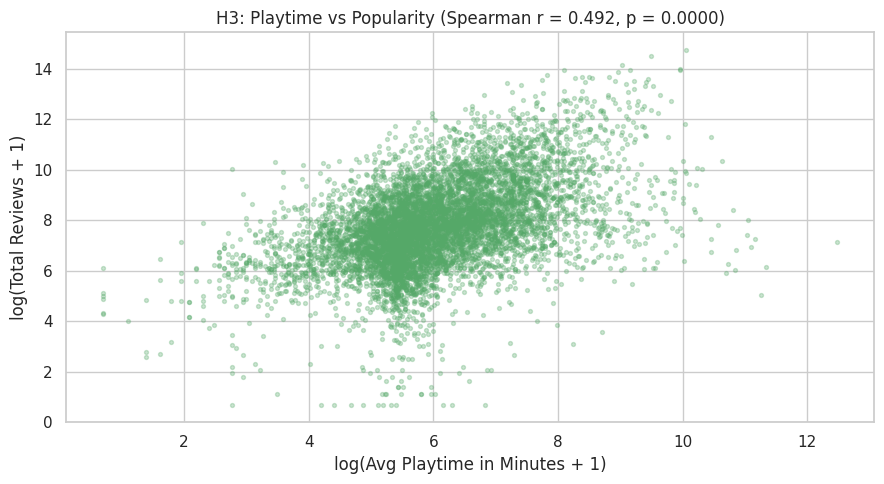

Saved: h3_playtime_vs_popularity.png

HYPOTHESIS 4: Game Genre vs Popularity
Median reviews by genre (top 10):
genre
Free To Play    69.0
RPG             36.0
Simulation      33.0
Adventure       27.0
Strategy        27.0
Indie           23.0
Sports          23.0
Action          22.0
Casual          18.0
Early Access    16.0

Kruskal-Wallis statistic: 3542.9680
P-value: 0.000000
Result: REJECT H0 — Game genre significantly influences popularity.


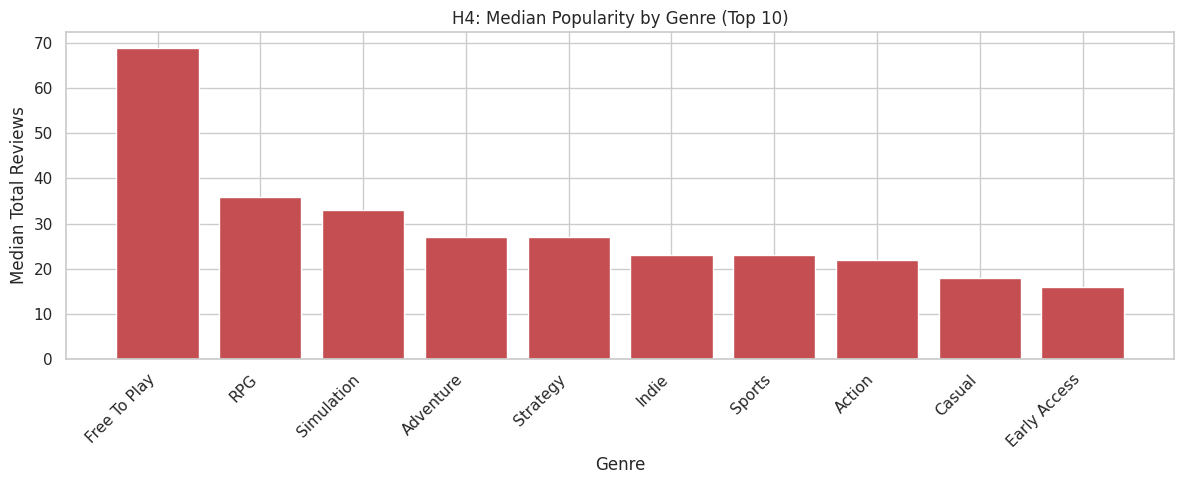

Saved: h4_genre_popularity.png

--- HYPOTHESIS 5: User Score vs Popularity ---
  n = 3

H5 — Spearman Correlation
Statistic: 1.0000
P-value: 0.000000
✅ Significant result (Reject H0)


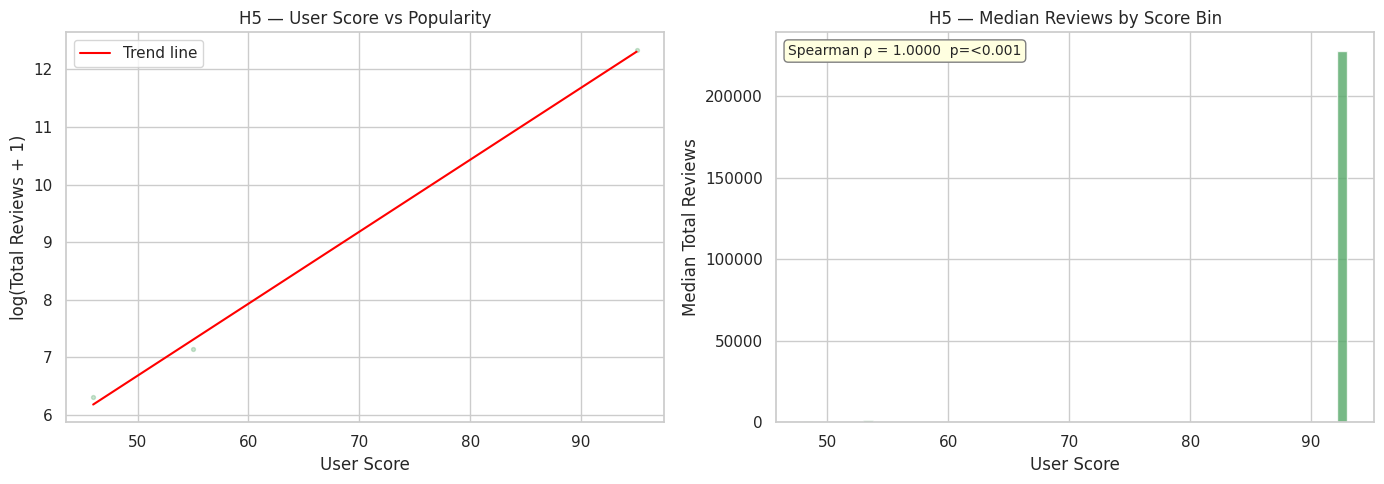

Saved: h5_score_vs_popularity.png

HYPOTHESIS TESTING SUMMARY
Hypothesis Test                      Significance
------------------------------------------------------------
H1         Mann-Whitney U            α = 0.05
H2         Kruskal-Wallis            α = 0.05
H3         Spearman Correlation      α = 0.05
H4         Kruskal-Wallis            α = 0.05
H5         Spearman Correlation      α = 0.05

Note: All tests are non-parametric due to the highly
skewed distribution of video game review counts.


In [14]:
# ============================================================
# DSA210 - Video Game Popularity Analysis
# Hypothesis Testing
#
# Research Question:
# How do pricing and ratings influence the popularity of video games?
#
# Hypotheses:
# H1: Free games are significantly more popular than paid games.
# H2: Popularity differs significantly across price categories.
# H3: Games with longer playtime are more popular.
# H4: Some genres are significantly more popular than others.
# H5: Higher-rated games are more popular.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12

# Load cleaned dataset
df = pd.read_csv("video_games_clean.csv")
print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")


# ============================================================
# HYPOTHESIS 1: Free vs Paid Games — Popularity
#
# H0: There is no significant difference in popularity
#     between free and paid games.
# H1: Free games are significantly more popular than paid games.
#
# Test: Mann-Whitney U Test (non-parametric, skewed distribution)
# ============================================================
print("\n" + "="*60)
print("HYPOTHESIS 1: Free vs Paid Games — Popularity")
print("="*60)

free_reviews = df[df["is_free"] == 1]["total_reviews"]
paid_reviews = df[df["is_free"] == 0]["total_reviews"]

stat, p = stats.mannwhitneyu(free_reviews, paid_reviews, alternative="greater")

print(f"Free games  — Median reviews: {free_reviews.median():,.0f}")
print(f"Paid games  — Median reviews: {paid_reviews.median():,.0f}")
print(f"Mann-Whitney U statistic: {stat:,.0f}")
print(f"P-value: {p:.6f}")

if p < 0.05:
    print("Result: REJECT H0 — Free games are significantly more popular than paid games.")
else:
    print("Result: FAIL TO REJECT H0 — No significant difference found.")

# Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_free", y=np.log1p(df["total_reviews"]),
            palette=["#DD8452", "#4C72B0"])
plt.xticks([0, 1], ["Paid", "Free"])
plt.title("H1: Popularity Distribution — Free vs Paid Games")
plt.xlabel("Game Type")
plt.ylabel("log(Total Reviews + 1)")
plt.tight_layout()
plt.savefig("h1_free_vs_paid.png", dpi=150)
plt.show()
print("Saved: h1_free_vs_paid.png")


# ============================================================
# HYPOTHESIS 2: Price Category vs Popularity
#
# H0: Popularity does not differ across price categories.
# H1: Popularity differs significantly across price categories.
#
# Test: Kruskal-Wallis Test (non-parametric ANOVA)
# ============================================================
print("\n" + "="*60)
print("HYPOTHESIS 2: Price Category vs Popularity")
print("="*60)

bins = [-1, 0, 999, 2999, 5999, 200000]
labels = ["Free", "$0.01-$9.99", "$10-$29.99", "$30-$59.99", "$60+"]
df["price_category"] = pd.cut(df["price"], bins=bins, labels=labels)

groups = [group["total_reviews"].values
          for _, group in df.groupby("price_category", observed=True)]

stat, p = stats.kruskal(*groups)

print("Median reviews by price category:")
print(df.groupby("price_category", observed=True)["total_reviews"].median().round(1).to_string())
print(f"\nKruskal-Wallis statistic: {stat:.4f}")
print(f"P-value: {p:.6f}")

if p < 0.05:
    print("Result: REJECT H0 — Popularity differs significantly across price categories.")
else:
    print("Result: FAIL TO REJECT H0 — No significant difference across price categories.")

# Visualization
cat_medians = df.groupby("price_category", observed=True)["total_reviews"].median()
plt.figure(figsize=(10, 5))
bars = plt.bar(cat_medians.index, cat_medians.values, color="#4C72B0", edgecolor="white")
for bar, val in zip(bars, cat_medians.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{int(val):,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.title("H2: Median Popularity by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Median Total Reviews")
plt.tight_layout()
plt.savefig("h2_price_category.png", dpi=150)
plt.show()
print("Saved: h2_price_category.png")


# ============================================================
# HYPOTHESIS 3: Playtime vs Popularity
#
# H0: There is no significant correlation between average
#     playtime and popularity.
# H1: Games with longer playtime are more popular.
#
# Test: Spearman Rank Correlation (non-parametric)
# ============================================================
print("\n" + "="*60)
print("HYPOTHESIS 3: Playtime vs Popularity")
print("="*60)

spy_df = df.dropna(subset=["avg_playtime_minutes"])
spy_df = spy_df[spy_df["avg_playtime_minutes"] > 0]

corr, p = stats.spearmanr(spy_df["avg_playtime_minutes"], spy_df["total_reviews"])

print(f"Games with playtime data: {spy_df.shape[0]:,}")
print(f"Spearman correlation (r): {corr:.4f}")
print(f"P-value: {p:.6f}")

if p < 0.05:
    direction = "positive" if corr > 0 else "negative"
    print(f"Result: REJECT H0 — There is a significant {direction} correlation between playtime and popularity.")
else:
    print("Result: FAIL TO REJECT H0 — No significant correlation found.")

# Visualization
plt.figure(figsize=(9, 5))
plt.scatter(np.log1p(spy_df["avg_playtime_minutes"]),
            np.log1p(spy_df["total_reviews"]),
            alpha=0.3, s=8, color="#55A868")
plt.title(f"H3: Playtime vs Popularity (Spearman r = {corr:.3f}, p = {p:.4f})")
plt.xlabel("log(Avg Playtime in Minutes + 1)")
plt.ylabel("log(Total Reviews + 1)")
plt.tight_layout()
plt.savefig("h3_playtime_vs_popularity.png", dpi=150)
plt.show()
print("Saved: h3_playtime_vs_popularity.png")


# ============================================================
# HYPOTHESIS 4: Game Genre vs Popularity
#
# H0: Game genre does not influence popularity.
# H1: Some genres are significantly more popular than others.
#
# Test: Kruskal-Wallis Test (non-parametric ANOVA)
# ============================================================
print("\n" + "="*60)
print("HYPOTHESIS 4: Game Genre vs Popularity")
print("="*60)

genre_df = df.dropna(subset=["genres"]).copy()
genre_df = genre_df.assign(genre=genre_df["genres"].str.split(",")).explode("genre")
genre_df["genre"] = genre_df["genre"].str.strip()

top_genres = genre_df["genre"].value_counts().head(10).index
genre_df = genre_df[genre_df["genre"].isin(top_genres)]

groups = [group["total_reviews"].values
          for _, group in genre_df.groupby("genre")]

stat, p = stats.kruskal(*groups)

print("Median reviews by genre (top 10):")
genre_medians = genre_df.groupby("genre")["total_reviews"].median().sort_values(ascending=False)
print(genre_medians.round(1).to_string())
print(f"\nKruskal-Wallis statistic: {stat:.4f}")
print(f"P-value: {p:.6f}")

if p < 0.05:
    print("Result: REJECT H0 — Game genre significantly influences popularity.")
else:
    print("Result: FAIL TO REJECT H0 — No significant difference across genres.")

# Visualization
plt.figure(figsize=(12, 5))
bars = plt.bar(genre_medians.index, genre_medians.values, color="#C44E52", edgecolor="white")
plt.title("H4: Median Popularity by Genre (Top 10)")
plt.xlabel("Genre")
plt.ylabel("Median Total Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("h4_genre_popularity.png", dpi=150)
plt.show()
print("Saved: h4_genre_popularity.png")


# ============================================================
# HYPOTHESIS 5
# User Score & Popularity: Do higher-rated games get more reviews?
#
# H₀: ρ = 0  (no correlation between user score and reviews)
# H₁: ρ > 0  (positive correlation — better rating = more popular)
# Test: Spearman correlation (one-tailed)
# ============================================================
print("\n--- HYPOTHESIS 5: User Score vs Popularity ---")

score_df = df[df["user_score"] > 0][["user_score", "total_reviews"]].dropna()

rho3, p_two3 = stats.spearmanr(score_df["user_score"], score_df["total_reviews"])
p_one3 = p_two3 / 2 if rho3 > 0 else 1 - p_two3 / 2

print(f"  n = {len(score_df):,}")
print_result(
    "H5 — Spearman Correlation",
    rho3, p_one3
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(score_df["user_score"], np.log1p(score_df["total_reviews"]),
                alpha=0.3, s=8, color="#55A868")
m3, b3 = np.polyfit(score_df["user_score"], np.log1p(score_df["total_reviews"]), 1)
x3 = np.linspace(score_df["user_score"].min(), score_df["user_score"].max(), 200)
axes[0].plot(x3, m3 * x3 + b3, color="red", linewidth=1.5, label="Trend line")
axes[0].set_title("H5 — User Score vs Popularity")
axes[0].set_xlabel("User Score")
axes[0].set_ylabel("log(Total Reviews + 1)")
axes[0].legend()

# Score bins
score_bins = pd.cut(score_df["user_score"], bins=10)
score_median = score_df.groupby(score_bins, observed=True)["total_reviews"].median()
score_mid    = [interval.mid for interval in score_median.index]
axes[1].bar(score_mid, score_median.values, color="#55A868", edgecolor="white", alpha=0.8)
axes[1].set_title("H5 — Median Reviews by Score Bin")
axes[1].set_xlabel("User Score")
axes[1].set_ylabel("Median Total Reviews")

rho_label3 = f"Spearman ρ = {rho3:.4f}  p={'<0.001' if p_one3 < 0.001 else f'{p_one3:.4f}'}"
axes[1].text(0.02, 0.97, rho_label3, transform=axes[1].transAxes,
             ha="left", va="top", fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))

plt.tight_layout()
plt.savefig("h5_score_vs_popularity.png", dpi=150)
plt.show()
print("Saved: h5_score_vs_popularity.png")

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "="*60)
print("HYPOTHESIS TESTING SUMMARY")
print("="*60)
print(f"{'Hypothesis':<10} {'Test':<25} {'Significance'}")
print("-"*60)
print(f"{'H1':<10} {'Mann-Whitney U':<25} {'α = 0.05'}")
print(f"{'H2':<10} {'Kruskal-Wallis':<25} {'α = 0.05'}")
print(f"{'H3':<10} {'Spearman Correlation':<25} {'α = 0.05'}")
print(f"{'H4':<10} {'Kruskal-Wallis':<25} {'α = 0.05'}")
print(f"{'H5':<10} {'Spearman Correlation':<25} {'α = 0.05'}")
print("\nNote: All tests are non-parametric due to the highly")
print("skewed distribution of video game review counts.")